<a href="https://colab.research.google.com/github/Shrushti88/Machine-Vision/blob/main/CM23006_6MV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practical 6

In [1]:
!pip -q install deepface tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.0 MB/s eta 0:00:00


In [2]:
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt
from google.colab import files

26-07-28 05:33:16 - Directory /root/.deepface has been created
26-07-28 05:33:16 - Directory /root/.deepface/weights has been created


Saving ubE0ThRNKKCYCLKn1mtpNoA3gHUcRWheW9UitXG6CgNGa4SkHxLNCOnsU9vKd1Cncf6PwLOXyPlMcKn3Q-NH8T-Vw9_B5_nkIKXkUnKHA3G433YOzIGiGGINOvevbhDgnX-On_ocCaW8TY9FC79rJbO5GKf4MBV8KOErjNLLAq4.jpg to ubE0ThRNKKCYCLKn1mtpNoA3gHUcRWheW9UitXG6CgNGa4SkHxLNCOnsU9vKd1Cncf6PwLOXyPlMcKn3Q-NH8T-Vw9_B5_nkIKXkUnKHA3G433YOzIGiGGINOvevbhDgnX-On_ocCaW8TY9FC79rJbO5GKf4MBV8KOErjNLLAq4.jpg


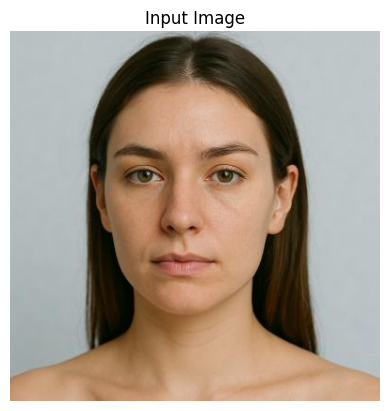

In [3]:
uploaded = files.upload()

filename = next(iter(uploaded))

img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

In [4]:
result = DeepFace.analyze(
    filename,
    actions=['emotion'],
    enforce_detection=False
)

print(result)

Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5


26-07-28 05:34:22 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


100%|██████████| 5.98M/5.98M [00:00<00:00, 79.0MB/s]


[{'emotion': {'angry': np.float32(0.016002372), 'disgust': np.float32(9.167994e-07), 'fear': np.float32(0.09227784), 'happy': np.float32(1.5682092e-05), 'sad': np.float32(2.46497), 'surprise': np.float32(7.9189226e-07), 'neutral': np.float32(97.42673)}, 'dominant_emotion': 'neutral', 'region': {'x': 74, 'y': 63, 'w': 225, 'h': 225, 'left_eye': (227, 153), 'right_eye': (140, 153)}, 'face_confidence': 0.89}]


In [5]:
emotion = result[0]['dominant_emotion']

print("Predicted Emotion:", emotion)

Predicted Emotion: neutral


In [6]:
scores = result[0]['emotion']

for emotion, score in scores.items():
    print(f"{emotion}: {score:.2f}%")

angry: 0.02%
disgust: 0.00%
fear: 0.09%
happy: 0.00%
sad: 2.46%
surprise: 0.00%
neutral: 97.43%


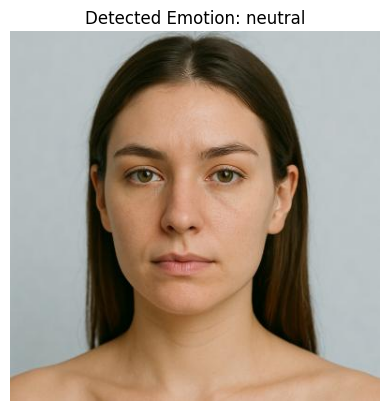

In [7]:
plt.imshow(img)
plt.title("Detected Emotion: " + emotion)
plt.axis("off")
plt.show()